In [12]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr, norm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json

In [ ]:
CONFIG = {
    'data_dir': '../data',
    'tickers': sorted([
        'AAPL', 'ABBV', 'ADBE', 'AIG', 'AMAT', 'AMD', 'AMZN', 'AVGO', 'AXON', 'BA', 
        'BAC', 'BLK', 'CAT', 'COST', 'CRM', 'CSCO', 'CVX', 'DE', 'DIS', 'GE', 
        'GOOGL', 'GS', 'HD', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'LLY', 'MA', 
        'MCD', 'META', 'MRK', 'MS', 'MSFT', 'MU', 'NFLX', 'NKE', 'NVDA', 'ORCL', 
        'PEP', 'PFE', 'PG', 'QCOM', 'SBUX', 'SPY', 'TSLA', 'TXN', 'UBER', 'UNH', 
        'V', 'WMT', 'XOM'
    ]),
    'model_path': 'best_model.pth',
    'seq_len': 60,
    'hidden_size': 64,
    'embedding_dim': 8,
    'layers': 2,
    'dropout': 0.0,
    'batch_size': 32,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',

    # Simulation Settings
    'transaction_cost_bps': 5,
    'top_k': 5,
    'confidence_threshold': 0.52,
    'initial_capital': 100_000,
    'test_start_date': '2023-01-01',
    'benchmark_ticker': 'SPY'
}

print(f"Phase 4 Backtest initialized on {CONFIG['device']}")

Phase 4 Backtest initialized on cpu


In [14]:
class CrossSectionalModel(nn.Module):
    def __init__(self, num_stocks, input_dim, hidden_dim, embed_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(num_stocks, embed_dim)
        self.lstm = nn.LSTM(
            input_dim, hidden_dim, num_layers=CONFIG['layers'], batch_first=True, dropout=dropout
        )
        combined_dim = hidden_dim + embed_dim
        self.head = nn.Sequential(
            nn.Linear(combined_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 2) # [Mu, Log_Var]
        )
        
    def forward(self, x, stock_ids):
        b, s, seq, f = x.shape
        x_flat = x.view(b * s, seq, f)
        lstm_out, _ = self.lstm(x_flat)
        last_step = lstm_out[:, -1, :] 
        
        if stock_ids.dim() == 1:
            stock_ids = stock_ids.repeat(b, 1)
            
        ids_flat = stock_ids.view(b * s)
        embeds = self.embedding(ids_flat)
        
        combined = torch.cat([last_step, embeds], dim=1)
        out = self.head(combined).view(b, s, 2)
        return out[:, :, 0], out[:, :, 1]

In [ ]:
class UniversalDataProcessor:
    def __init__(self, data_dir, tickers, use_residuals=False, market_ticker='SPY'):
        self.data_dir = Path(data_dir)
        self.tickers = sorted(tickers)
        self.stock_to_id = {ticker: i for i, ticker in enumerate(self.tickers)}
        self.use_residuals = use_residuals
        self.market_ticker = market_ticker
        
    def load_and_process(self):
        print("Loading data for backtest...")
        dfs = []
        for ticker in self.tickers:
            fpath = self.data_dir / f"{ticker}.csv"
            if fpath.exists():
                df = pd.read_csv(fpath)
                df.columns = df.columns.str.strip().str.title()
                df['Date'] = pd.to_datetime(df['Date'])
                df = df.set_index('Date').sort_index()
                df = self._engineer_features(df)
                df['Ticker'] = ticker
                df['Stock_ID'] = self.stock_to_id[ticker]
                dfs.append(df)

        common_index = dfs[0].index
        for df in dfs[1:]: common_index = common_index.intersection(df.index)
        
        aligned_dfs = [df.loc[common_index] for df in dfs]
        universal_df = pd.concat(aligned_dfs).reset_index()
        
        # Z-Score Normalization
        feature_cols = [c for c in universal_df.columns if c not in ['Date', 'Ticker', 'Stock_ID', 'Target_5D', 'Log_Ret_Raw']]
        universal_df[feature_cols] = universal_df.groupby('Date')[feature_cols].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        ).clip(-3, 3)
        
        # Residual Targets (subtract beta * market return)
        if self.use_residuals and self.market_ticker in self.tickers:
            print("Computing residual returns...")
            # Pivot for matrix ops
            log_ret_matrix = universal_df.pivot(index='Date', columns='Ticker', values='Log_Ret_Raw')
            target_matrix = universal_df.pivot(index='Date', columns='Ticker', values='Target_5D')
            
            market_ret = log_ret_matrix[self.market_ticker]
            market_target = target_matrix[self.market_ticker]
            
            for ticker in self.tickers:
                if ticker == self.market_ticker: continue
                stock_ret = log_ret_matrix[ticker]
                cov = stock_ret.rolling(60).cov(market_ret)
                var = market_ret.rolling(60).var()
                beta = cov / var
                
                # Align beta to universal_df dates for this ticker
                beta = beta.reindex(universal_df[universal_df['Ticker'] == ticker]['Date'])
                beta = beta.ffill()  # Forward fill for NaNs at start
                
                # Subtract
                universal_df.loc[universal_df['Ticker'] == ticker, 'Target_5D'] -= beta.values * market_target.reindex(beta.index).values
                
        self.feature_cols = feature_cols
        return universal_df

    def _engineer_features(self, df):
        df = df.copy()
        df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
        df['Log_Ret_Raw'] = df['Log_Ret']
        df['Target_5D'] = df['Log_Ret_Raw'].rolling(20).sum().shift(-20)
        for p in [20, 60]:
            sma = df['Close'].rolling(p).mean()
            df[f'Dist_SMA_{p}'] = (df['Close'] / sma) - 1
        df['Vol_20'] = df['Log_Ret'].rolling(20).std()
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).ewm(span=14).mean()
        loss = (-delta.where(delta < 0, 0)).ewm(span=14).mean()
        rs = gain / loss.replace(0, 1e-9)
        df['RSI'] = (100 - (100 / (1 + rs))) / 100.0
        return df.dropna()

In [16]:
class UniversalDataset(Dataset):
    def __init__(self, df, feature_cols, seq_len, num_stocks):
        self.seq_len = seq_len
        self.num_stocks = num_stocks
        unique_dates = df['Date'].unique()
        self.num_days = len(unique_dates)
        self.X = np.zeros((self.num_days, num_stocks, len(feature_cols)), dtype=np.float32)
        self.Y = np.zeros((self.num_days, num_stocks), dtype=np.float32)
        self.IDs = np.arange(num_stocks)
        
        for i, feat in enumerate(feature_cols):
            self.X[:, :, i] = df.pivot(index='Date', columns='Ticker', values=feat).values
        self.Y = df.pivot(index='Date', columns='Ticker', values='Target_5D').values
        
    def __len__(self): return self.num_days - self.seq_len
    def __getitem__(self, idx):
        x = self.X[idx : idx + self.seq_len].transpose(1, 0, 2)
        return torch.FloatTensor(x), torch.LongTensor(self.IDs), torch.FloatTensor(self.Y[idx + self.seq_len - 1])

In [ ]:
processor = UniversalDataProcessor(CONFIG['data_dir'], CONFIG['tickers'], use_residuals=True)
universal_df = processor.load_and_process()

# Prepare test set from 2023 onwards
test_df = universal_df[universal_df['Date'] >= CONFIG['test_start_date']]
test_ds = UniversalDataset(test_df, processor.feature_cols, CONFIG['seq_len'], len(CONFIG['tickers']))
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

print(f"Test Set: {len(test_df['Date'].unique())} days")

# Load model
model = CrossSectionalModel(
    num_stocks=len(CONFIG['tickers']),
    input_dim=len(processor.feature_cols),
    hidden_dim=CONFIG['hidden_size'],
    embed_dim=CONFIG['embedding_dim'],
    dropout=CONFIG['dropout']
).to(CONFIG['device'])

try:
    model.load_state_dict(torch.load(CONFIG['model_path'], map_location=CONFIG['device']))
    print("Model weights loaded successfully.")
except FileNotFoundError:
    print("WARNING: Model weights not found. Please ensure 'best_model.pth' is in the directory.")

Loading data for backtest...


Computing residual returns...
Test Set: 708 days
Model weights loaded successfully.


In [18]:
def generate_signals(model, loader, date_index, tickers):
    model.eval()
    results = []
    current_day_idx = 0
    
    with torch.no_grad():
        for x, ids, y in loader:
            x, ids, y = x.to(CONFIG['device']), ids.to(CONFIG['device']), y.to(CONFIG['device'])
            mu, log_var = model(x, ids)
            sigma = torch.exp(0.5 * log_var)
            
            mu_np = mu.cpu().numpy()
            sigma_np = sigma.cpu().numpy()
            y_np = y.cpu().numpy()
            
            for i in range(len(mu_np)):
                if current_day_idx >= len(date_index): break
                date = date_index[current_day_idx]
                
                for j, ticker in enumerate(tickers):
                    results.append({
                        'Date': date,
                        'Ticker': ticker,
                        'Pred_Mu': mu_np[i, j],
                        'Pred_Sigma': sigma_np[i, j],
                        'Actual_5D_Return': y_np[i, j]
                    })
                current_day_idx += 1
                
    return pd.DataFrame(results)

# Get valid dates corresponding to loader outputs
valid_dates = test_df['Date'].unique()[CONFIG['seq_len']:]
signal_df = generate_signals(model, test_loader, valid_dates, processor.tickers)
print(f"Generated {len(signal_df)} signals.")
signal_df.head()

Generated 34344 signals.


,Date,Ticker,Pred_Mu,Pred_Sigma,Actual_5D_Return
0,2023-03-30,AAPL,0.223937,4.015213,1.612421
1,2023-03-30,ABBV,0.136639,2.747531,-6.735017
2,2023-03-30,ADBE,0.155760,4.762408,-6.350476
3,2023-03-30,AIG,0.197741,8.904969,3.778570
4,2023-03-30,AMAT,0.183476,6.732816,-11.496313


Purged Weekly IC: 0.0614 (Target > 0.03)


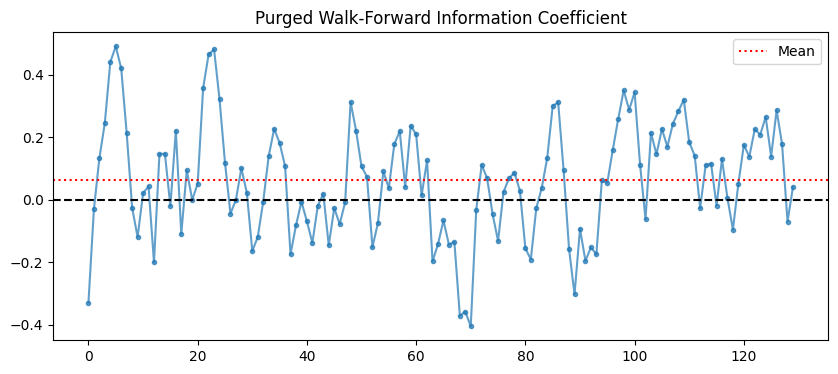

In [ ]:
def analyze_purged_ic(df, horizon=5):
    pred_matrix = df.pivot(index='Date', columns='Ticker', values='Pred_Mu')
    actual_matrix = df.pivot(index='Date', columns='Ticker', values='Actual_5D_Return')
    
    # Purged: use every horizon-th row only
    purged_idx = []
    dates = pred_matrix.index
    i = 0
    while i < len(dates):
        purged_idx.append(dates[i])
        i += horizon
    
    purged_preds = pred_matrix.loc[purged_idx]
    purged_actuals = actual_matrix.loc[purged_idx]
    
    ics = []
    for date in purged_preds.index:
        p = purged_preds.loc[date].values
        a = purged_actuals.loc[date].values
        ic, _ = spearmanr(p, a)
        if not np.isnan(ic):
            ics.append(ic)
            
    return np.mean(ics), ics

mean_ic, ic_series = analyze_purged_ic(signal_df)
print(f"Purged Weekly IC: {mean_ic:.4f} (Target > 0.03)")

plt.figure(figsize=(10, 4))
plt.plot(ic_series, marker='.', linestyle='-', alpha=0.7)
plt.axhline(0, color='black', linestyle='--')
plt.axhline(mean_ic, color='red', linestyle=':', label='Mean')
plt.title("Purged Walk-Forward Information Coefficient")
plt.legend()
plt.show()

In [ ]:
class VectorizedBacktester:
    def __init__(self, signals, config):
        self.signals = signals.copy()
        self.config = config

    def run(self):
        mu_matrix    = self.signals.pivot(index='Date', columns='Ticker', values='Pred_Mu')
        sigma_matrix = self.signals.pivot(index='Date', columns='Ticker', values='Pred_Sigma')
        ret_matrix   = self.signals.pivot(index='Date', columns='Ticker', values='Actual_5D_Return').shift(5)

        valid_dates = ret_matrix.dropna(how='all').index
        mu_matrix    = mu_matrix.loc[valid_dates]
        sigma_matrix = sigma_matrix.loc[valid_dates]
        ret_matrix   = ret_matrix.loc[valid_dates]

        trade_dates = mu_matrix.index[::5]

        equity = self.config['initial_capital']
        equity_curve = [equity]
        prev_longs = set()
        prev_shorts = set()
        turnover_list = []

        for date in trade_dates:
            preds = mu_matrix.loc[date]

            # Apply confidence filter for predicted returns
            probs = 1 - norm.cdf(0, preds, sigma_matrix.loc[date])
            high_conf = probs >= self.config['confidence_threshold']

            # Always rebalance: if too few high-confidence stocks, use all stocks
            if high_conf.sum() < self.config['top_k'] * 2:
                ranked = preds.sort_values(ascending=False)
            else:
                ranked = preds[high_conf].sort_values(ascending=False)

            longs  = ranked.head(self.config['top_k']).index.tolist()
            shorts = ranked.tail(self.config['top_k']).index.tolist()

            long_ret  = ret_matrix.loc[date, longs].mean()
            short_ret = -ret_matrix.loc[date, shorts].mean()
            gross_ret = 0.5 * long_ret + 0.5 * short_ret

            changes = len(set(longs) ^ prev_longs) + len(set(shorts) ^ prev_shorts)
            turnover = changes / (2 * self.config['top_k'])
            turnover_list.append(turnover)
            cost = turnover * (self.config['transaction_cost_bps'] / 10000.0) * 2

            net_ret = gross_ret - cost
            equity *= (1 + net_ret / 100.0)
            equity_curve.append(equity)
            prev_longs, prev_shorts = set(longs), set(shorts)

        print(f"Avg turnover: {np.mean(turnover_list):.3f}")
        equity_dates = [mu_matrix.index[0]] + list(trade_dates)
        return pd.Series(equity_curve, index=equity_dates)

Avg turnover: 0.416
Total Return: 64.92%
Sharpe Ratio: 1.11
Max Drawdown: -31.49%


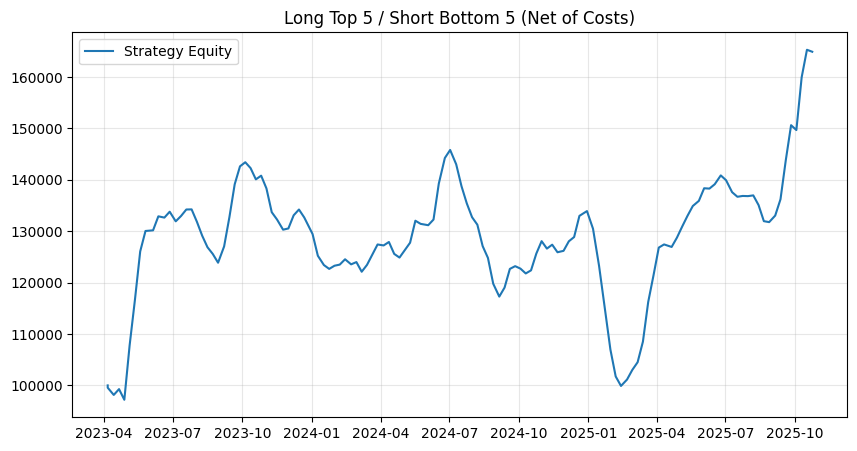

In [ ]:
tester = VectorizedBacktester(signal_df, CONFIG)
equity_curve = tester.run()

total_ret = (equity_curve.iloc[-1] / CONFIG['initial_capital']) - 1
returns = equity_curve.pct_change().dropna()
mean_ret = returns.mean()
std_ret = returns.std()
num_rebalances_per_year = 252 / 5  # Approx 50.4
sharpe = mean_ret / std_ret * np.sqrt(num_rebalances_per_year) if std_ret > 0 else 0
print(f"Total Return: {total_ret*100:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")

# Max drawdown calculation
cummax = equity_curve.cummax()
drawdowns = (equity_curve - cummax) / cummax
max_dd = drawdowns.min() * 100
print(f"Max Drawdown: {max_dd:.2f}%")

plt.figure(figsize=(10, 5))
plt.plot(equity_curve, label='Strategy Equity')
plt.title("Long Top 5 / Short Bottom 5 (Net of Costs)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
def export_deployment_json(df, filename="latest_inference.json"):
    latest_date = df['Date'].max()
    today_df = df[df['Date'] == latest_date].copy()
    
    today_df['Rank'] = today_df['Pred_Mu'].rank(ascending=False)
    
    output = {
        "metadata": {"date": latest_date.strftime('%Y-%m-%d'), "model_version": "v1.0"},
        "signals": []
    }
    
    for _, row in today_df.iterrows():
        # Confidence as probability predicted return > 0 under Normal distribution
        conf = int((1 - norm.cdf(0, row['Pred_Mu'], row['Pred_Sigma'])) * 100)
        conf = max(0, min(100, conf))
        
        output['signals'].append({
            "ticker": row['Ticker'],
            "pred_5d_return": round(row['Pred_Mu'], 2),
            "uncertainty": round(row['Pred_Sigma'], 2),
            "confidence": conf,
            "rank": int(row['Rank'])
        })
        
    output['signals'].sort(key=lambda x: x['rank'])
    
    with open(filename, 'w') as f:
        json.dump(output, f, indent=2)
    print(f"Exported signals to {filename}")

export_deployment_json(signal_df)

Exported signals to latest_inference.json
